# Fast convolution

So, the english is not very good, I will improve that

In [9]:
import itertools

import sympy as sy
import numpy as np

In [10]:
from fast_convolution import fast

In [11]:
import fitz

In [12]:
from utils import plot_pdf

ModuleNotFoundError: No module named 'utils'

In [13]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [14]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.
Is an excellent book but full of examples but, of course, do not explain everything in details.
For that parts I will quote another books and videos from YouTube.

The book puts first all theory and only after that we have a detailed example. To better understanding in this tutorial we have quotes from theory and examples together fallowing the sequence of commands

This example will not work for different vector sizes.

In [15]:
plot_pdf(doc[0], dpi=100)

NameError: name 'plot_pdf' is not defined

In [16]:
plot_pdf(doc[163], [.76, .95])

NameError: name 'plot_pdf' is not defined

In [17]:
plot_pdf(doc[165], [0, .322])

NameError: name 'plot_pdf' is not defined

## Start

Size of vectors

In [18]:
d_num = 2
g_num = 2

Example of vectors for the convolution

In [19]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2] [1, 2]


Polynomial degree

In [20]:
b_degree = d_num + g_num - 1
b_degree

In [21]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

1 1


In [22]:
x = sy.symbols("x")
x

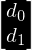

In [23]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
di

In [24]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
gi

In [25]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

In [26]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

In [27]:
sx = gx*dx
sx

In [28]:
xi = [x**i for i in range(1, sy.degree(sx.expand(), x) + 1)]
xi

In [29]:
plot_pdf(doc[165], [.31, .57])

NameError: name 'plot_pdf' is not defined

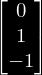

In [30]:
bi = [0, 1, -1]
sy.Matrix(bi)

In [31]:
plot_pdf(doc[165], [.57, .875])

NameError: name 'plot_pdf' is not defined

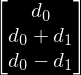

In [32]:
dbi = [di[0] + di[1] * b for b in bi]
sy.Matrix(dbi)

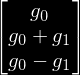

In [33]:
gbi = [gi[0] + gi[1] * b for b in bi]
sy.Matrix(gbi)

In [34]:
plot_pdf(doc[165], [.87, .95])

NameError: name 'plot_pdf' is not defined

In [35]:
plot_pdf(doc[166], [0, .21])

NameError: name 'plot_pdf' is not defined

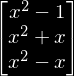

In [36]:
cd = [sy.expand((x - b[0])*(x - b[1])) for b0, b in zip(bi, itertools.combinations(reversed(bi), len(bi)-1))]
sy.Matrix(cd)

In [37]:
cq = [1/sy.expand((b0 - b[0])*(b0 - b[1])) for b0, b in zip(bi, itertools.combinations(reversed(bi), len(bi)-1))]
sy.Matrix([cq])

In [38]:
plot_pdf(doc[166], [.2, .3])

NameError: name 'plot_pdf' is not defined

In [39]:
c0 = sy.Matrix([s.subs({x:0}) for s in cd])
c0.T

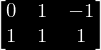

In [40]:
c1 = sy.Matrix([[d.coeff(c, 1) for c in xi] for d in cd])
c1.T

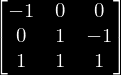

In [41]:
c_mtx = sy.Matrix(c0.T.tolist() + c1.T.tolist())
c_mtx

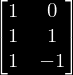

In [42]:
a_mtx = sy.Matrix([[b.coeff(d, 1) for d in di] for b in dbi])
a_mtx

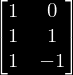

In [43]:
b_mtx = sy.Matrix([[b.coeff(g, 1) for g in gi] for b in gbi])
b_mtx

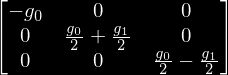

In [44]:
bg_mtx = sy.diag(*(sy.diag(*cq) * b_mtx * gi).tolist())
bg_mtx

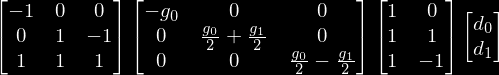

In [45]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di))
s

## Example

In [46]:
subs = {k[0]: v for k, v in zip(di.tolist()+gi.tolist(), d_values + g_values)}
subs

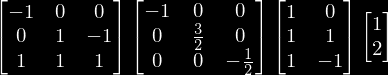

In [47]:
si = s.subs(subs)
si

In [48]:
sy.expand(sx)

Let's compare the output polynomial matrix from direct and winograd method

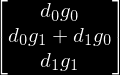

In [49]:
sy.Matrix(np.convolve(np.array(di).reshape(-1), np.array(gi).reshape(-1)))

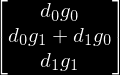

In [50]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di), evaluate=True)
se

Comparing numerical outputs from direct and winograd method

In [51]:
sy.Matrix(np.convolve(d_values, g_values))

In [52]:
se.subs(subs)

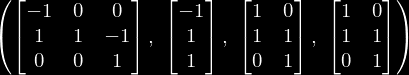

In [55]:
c, q, b, m = fast.toom_cook(2, 2, [0, 1, np.inf])
(c, q, b, m)

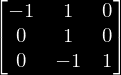

In [56]:
c.T